Question 4

In [3]:
import pandas as pd
import numpy as np

In [4]:
returns = pd.read_csv("./processed_data/stock_excess_monthly.csv")
returns.head()


,Unnamed: 0,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
0,2015-03-31,-0.009829,-0.034014,-0.030641,-0.016088,0.035693,0.028604,-0.050217,0.074302,0.005257,...,0.019169,-0.034745,-0.099366,0.014444,-0.026841,-0.020469,-0.018646,-0.012013,-0.004928,-0.000220
1,2015-04-30,-0.005942,0.004169,0.106092,0.005443,-0.016648,-0.002125,0.026668,-0.020185,0.029145,...,0.007696,-0.052338,-0.126769,-0.027795,0.025900,0.053939,0.091635,-0.069184,0.013280,-0.041043
2,2015-05-31,-0.006086,0.042616,0.027686,0.044168,0.049823,0.034211,0.037339,0.098645,0.081648,...,-0.026079,0.031055,-0.095432,0.002395,-0.018639,-0.010135,0.045424,0.038199,0.172819,0.111997
3,2015-06-30,-0.065001,-0.039978,0.006930,0.007788,0.044893,0.005636,0.021947,-0.059111,-0.093723,...,-0.007259,-0.026151,-0.022305,-0.048630,-0.025793,0.011540,-0.002373,-0.045571,0.010739,-0.033678
4,2015-07-31,0.057611,-0.035487,0.046502,0.035089,0.061636,0.061349,0.010019,-0.097737,-0.018736,...,-0.010786,-0.028057,0.043172,0.072524,-0.051151,-0.072986,-0.023631,-0.050398,-0.033287,0.013632


In [5]:
t = returns.shape[0]
n_stocks = 50
n_pools = 1000


def make_subpools(df, n_pools, n_stocks, seed=None):
    if seed is not None:
        np.random.seed(seed)
    cols = df.columns.drop("Unnamed: 0")
    return {
        i: np.random.choice(cols, size=n_stocks, replace=False) for i in range(n_pools)
    }


subpools = make_subpools(returns, n_pools, n_stocks, seed=42)

results = {}


def calculate_theta_s(returns):
    mu = returns.mean(axis=0).values.reshape(-1, 1)
    Sigma = returns.cov().values

    return (mu.T @ np.linalg.solve(Sigma, mu)).item()


for key, pool in subpools.items():
    pool_returns = returns[pool]

    theta_kz = ((t - n_stocks - 2) * calculate_theta_s(pool_returns) - n_stocks) / t

    results[key] = {"stocks": pool, "theta": theta_kz}


4.1 a)

In [6]:
# Extract theta_kz values and compute distribution statistics
thetas = np.array([results[key]["theta"] for key in results.keys()])

median_theta = np.median(thetas)
percentile_95 = np.percentile(thetas, 95)
max_theta = np.max(thetas)
n_negative = np.sum(thetas < 0)

print(f"Distribution of θ_KZ across {len(thetas)} subpools:")
print(f"  Median:        {median_theta:.6f}")
print(f"  95th percentile: {percentile_95:.6f}")
print(f"  Maximum:       {max_theta:.6f}")
print(f"  # negative:    {n_negative}")


Distribution of θ_KZ across 1000 subpools:
  Median:        -0.058304
  95th percentile: 0.086670
  Maximum:       0.500006
  # negative:    759


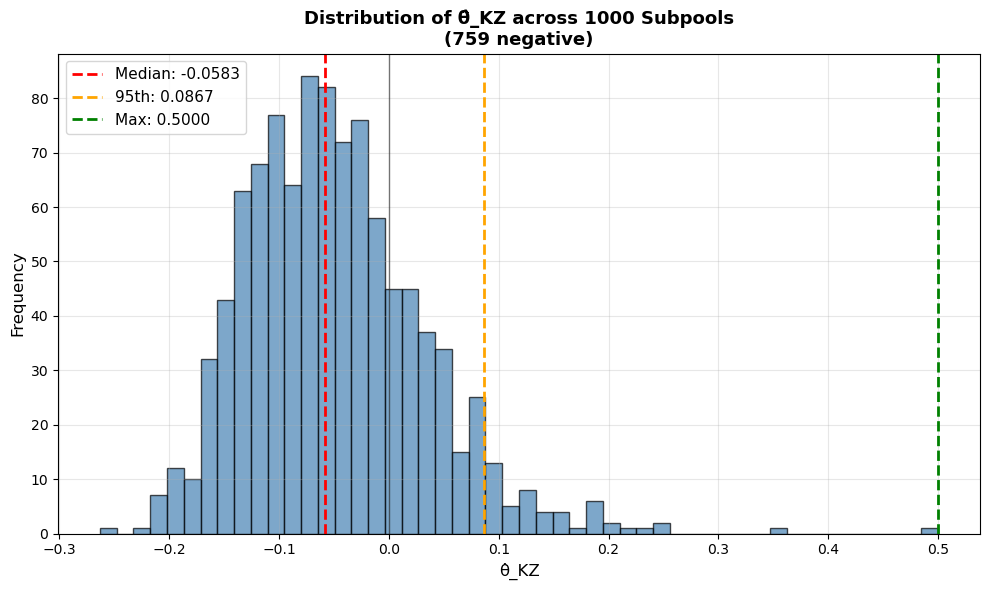

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(thetas, bins=50, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(
    median_theta,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_theta:.4f}",
)
ax.axvline(
    percentile_95,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"95th: {percentile_95:.4f}",
)
ax.axvline(
    max_theta, color="green", linestyle="--", linewidth=2, label=f"Max: {max_theta:.4f}"
)
ax.axvline(0, color="black", linestyle="-", linewidth=1, alpha=0.5)

ax.set_xlabel("θ̂_KZ", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(
    f"Distribution of θ̂_KZ across {len(thetas)} Subpools\n({n_negative} negative)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("theta_kz_histogram.png", dpi=300, bbox_inches="tight")
plt.show()


4.1 b)

In [8]:
# Find the subpool with theta closest to the 95th percentile
selected_pool_key = min(
    results.keys(), key=lambda k: abs(results[k]["theta"] - percentile_95)
)
selected_pool_theta = results[selected_pool_key]["theta"]
selected_pool_tickers = results[selected_pool_key]["stocks"]

print(f"Subpool at 95th percentile:")
print(f"  Pool Index: {selected_pool_key}")
print(f"  θ_KZ: {selected_pool_theta:.6f}")
print(f"\nStocks in this pool ({len(selected_pool_tickers)} tickers):")
print(sorted(selected_pool_tickers))


Subpool at 95th percentile:
  Pool Index: 35
  θ_KZ: 0.086650

Stocks in this pool (50 tickers):
['ABBV', 'ADP', 'AEE', 'ARE', 'AVB', 'BAX', 'BEN', 'BF-B', 'BK', 'BRK-B', 'CMG', 'COF', 'COST', 'CRL', 'CVX', 'D', 'DAL', 'DGX', 'DHR', 'DLTR', 'DOV', 'ELV', 'EXPE', 'FDX', 'FI', 'FTNT', 'HRL', 'HSY', 'INTU', 'IRM', 'JPM', 'LHX', 'LII', 'MA', 'MCHP', 'MRK', 'MSFT', 'NDSN', 'OXY', 'PCAR', 'PFG', 'PODD', 'RJF', 'SBAC', 'SPGI', 'SWKS', 'TXT', 'UNP', 'XYL', 'ZTS']


4.2 a)

In [9]:
import scipy.special

subpool = returns[selected_pool_tickers]

theta_s = calculate_theta_s(subpool)
theta_kz = results[selected_pool_key]["theta"]


def calculate_ALZ(returns):
    theta_s = calculate_theta_s(returns)

    x = theta_s / (1 + theta_s)
    a = n_stocks / 2
    b = (t - n_stocks) / 2
    I = scipy.special.betainc(a, b, x)
    B = scipy.special.beta(a, b)

    numerator = 2 * theta_s ** (n_stocks / 2) * (1 + theta_s) ** (-(t - 2) / 2)
    denominator = t * I * B

    return numerator / denominator


ALZ = calculate_ALZ(subpool)

print(f"95th percentile subpool information:")
print(f"  θ_s: {theta_s:.6f}")
print(f"  θ_KZ: {theta_kz:.6f}")
print(f"  ALZ Correction: {ALZ:.6f}")

95th percentile subpool information:
  θ_s: 0.876590
  θ_KZ: 0.086650
  ALZ Correction: 0.041158


In [10]:
diff_in_pct = (theta_kz - ALZ) / theta_kz * 100
print(f"Difference in percentage: {diff_in_pct:.2f}%")

Difference in percentage: 52.50%


The bias correction is 52.50% of the plug-in estimate

4.2 b)

It is small rn (50/121) so I dont really understand this question

4.2 c)

In [11]:
theta = theta_kz + ALZ

sigma = 0.15
sigma_m = sigma / np.sqrt(12)

rc = sigma_m * (1 + theta) / np.sqrt(theta)
print(rc)

0.13660152947892712


4.3 a)

In [12]:
subpool

,D,FTNT,DHR,ADP,BAX,BEN,COF,DOV,FDX,BK,...,CVX,DLTR,MCHP,BRK-B,INTU,JPM,SWKS,FI,SBAC,IRM
0,0.002158,0.035200,-0.014096,-0.006663,-0.004699,-0.037033,0.000642,-0.037187,-0.054305,0.018564,...,-0.003230,0.027362,-0.052933,-0.005666,-0.006558,-0.026781,0.084820,0.016529,-0.070316,-0.001791
1,0.009764,0.075202,-0.037820,-0.014528,0.001897,0.003065,0.023828,0.089598,0.022997,0.053245,...,0.054701,-0.061786,-0.027285,-0.023385,0.035137,0.048312,-0.065021,-0.024531,-0.012591,-0.057695
2,-0.008938,0.057933,0.051082,0.009683,-0.025415,-0.014412,0.036096,-0.000764,0.019572,0.022080,...,-0.067152,-0.020484,0.035988,0.010871,0.035642,0.037338,0.169757,0.030607,-0.036962,0.054095
3,-0.055185,0.029171,-0.008956,-0.059866,0.046600,-0.036681,0.049391,-0.073784,-0.017084,-0.034622,...,-0.067536,0.049927,-0.037255,-0.051421,-0.035031,0.027617,-0.051333,0.030851,0.025831,-0.149564
4,0.067734,0.142175,0.065420,-0.007756,0.051685,-0.075628,-0.080856,-0.093093,0.003962,0.035389,...,-0.088462,-0.014234,-0.103789,0.045555,0.048837,0.015808,-0.086453,0.045501,0.046797,-0.033131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,-0.005151,0.186054,-0.027817,0.056148,-0.055454,0.088280,0.165111,0.083181,0.096848,0.079641,...,0.091361,0.094427,-0.069861,0.065553,0.047002,0.114809,-0.003100,0.107005,-0.012851,-0.003700
117,-0.090484,-0.009596,-0.045639,-0.045782,-0.148578,-0.102848,-0.077549,-0.096660,-0.071767,-0.067119,...,-0.115116,0.046631,-0.176413,-0.067129,-0.024413,-0.044492,0.016728,-0.076506,-0.108083,-0.159780
118,0.028026,0.061954,-0.033705,0.030926,0.106697,0.088175,0.129528,0.078649,-0.063879,0.113842,...,0.026002,-0.025035,-0.058238,0.029799,-0.045820,0.110504,-0.002688,0.046817,-0.034686,-0.037849
119,0.026973,0.065009,-0.072905,0.036095,0.059736,-0.097021,-0.015945,-0.025061,-0.010749,0.031258,...,0.069038,-0.009986,0.084833,0.088710,0.017008,-0.013247,-0.279145,0.083770,0.094711,-0.089606


In [13]:
import numpy as np
from sklearn.linear_model import lars_path
from sklearn.model_selection import KFold

# setup: rc, R-> and target sigma monthly
R = subpool.values
r_hat = np.full(R.shape[0], rc)  # making it as a vector : (rc,rc,rc,rc,rc,rc,....)
sigma_monthly = sigma_m

# --- Step 1: 10-Fold CV  ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)
zeta_chosen = []


# Split R and rc to match the size of training and Testing

for train_idx, val_idx in kf.split(R):
    R_train, R_val = R[train_idx], R[val_idx]
    r_train = r_hat[train_idx]

    """
    LARS path on training set :or every possible λ at once, returning coefs_train of shape (50 × n_steps).
    Each column is a different portfolio solution, from fully sparse (all zeros) to OLS (no penalty).
    """
    _, _, coefs_train = lars_path(R_train, r_train, method="lasso")
    w_ols_train = coefs_train[:, -1]  # unpenalized OLS
    ols_l1 = np.sum(np.abs(w_ols_train))

    if ols_l1 == 0:
        continue

    zeta_train = np.sum(np.abs(coefs_train), axis=0) / ols_l1  # computing Zeta_train

    # Validation volatility at each step
    vols = [np.std(R_val @ coefs_train[:, i]) for i in range(coefs_train.shape[1])]

    best_idx = np.argmin(np.abs(np.array(vols) - sigma_monthly))
    zeta_chosen.append(zeta_train[best_idx])

zeta_avg = np.mean(zeta_chosen)
print(f"Averaged ζ̂ = {zeta_avg:.4f}")

# --- Step 2: Full-sample LARS path ---
# Rerun LARS path with optimized Zeta
_, _, coefs_full = lars_path(R, r_hat, method="lasso")
w_ols_full = coefs_full[:, -1]
zeta_full = np.sum(np.abs(coefs_full), axis=0) / np.sum(np.abs(w_ols_full))

# --- Step 3: Extract weights at ζ̂ ---
best_idx_full = np.argmin(np.abs(zeta_full - zeta_avg))
w_final = coefs_full[:, best_idx_full]

# --- Step 4: Report ---
nonzero_mask = np.abs(w_final) > 1e-6
print(f"Number of nonzero weights: {nonzero_mask.sum()}")

weights_series = pd.Series(w_final, index=subpool.columns)
print(weights_series[nonzero_mask].sort_values(ascending=False))

Averaged ζ̂ = 0.1954
Number of nonzero weights: 22
MSFT    0.356808
JPM     0.288580
LII     0.208079
COST    0.174197
MA      0.117094
FI      0.102540
FTNT    0.092051
DHR     0.088690
ABBV    0.080543
IRM     0.079921
AEE     0.045586
PODD    0.029570
PCAR    0.009726
OXY    -0.006989
DAL    -0.016968
FDX    -0.079424
SWKS   -0.105694
TXT    -0.113269
ARE    -0.118086
BAX    -0.120947
BF-B   -0.128663
BEN    -0.324919
dtype: float64


In [14]:
print(weights_series)

D        0.000000
FTNT     0.092051
DHR      0.088690
ADP      0.000000
BAX     -0.120947
BEN     -0.324919
COF      0.000000
DOV      0.000000
FDX     -0.079424
BK       0.000000
LII      0.208079
OXY     -0.006989
MA       0.117094
UNP      0.000000
XYL      0.000000
ARE     -0.118086
MSFT     0.356808
COST     0.174197
TXT     -0.113269
CRL      0.000000
NDSN     0.000000
SPGI     0.000000
LHX      0.000000
AVB      0.000000
BF-B    -0.128663
HRL      0.000000
AEE      0.045586
PFG      0.000000
PODD     0.029570
EXPE     0.000000
MRK      0.000000
ABBV     0.080543
RJF      0.000000
ZTS      0.000000
ELV      0.000000
CMG      0.000000
HSY      0.000000
PCAR     0.009726
DGX      0.000000
DAL     -0.016968
CVX      0.000000
DLTR     0.000000
MCHP     0.000000
BRK-B    0.000000
INTU     0.000000
JPM      0.288580
SWKS    -0.105694
FI       0.102540
SBAC     0.000000
IRM      0.079921
dtype: float64


## 4.4 Plug-In vs Maxser: Comparison

Plugin cash weight (1 - sum): 0.3041


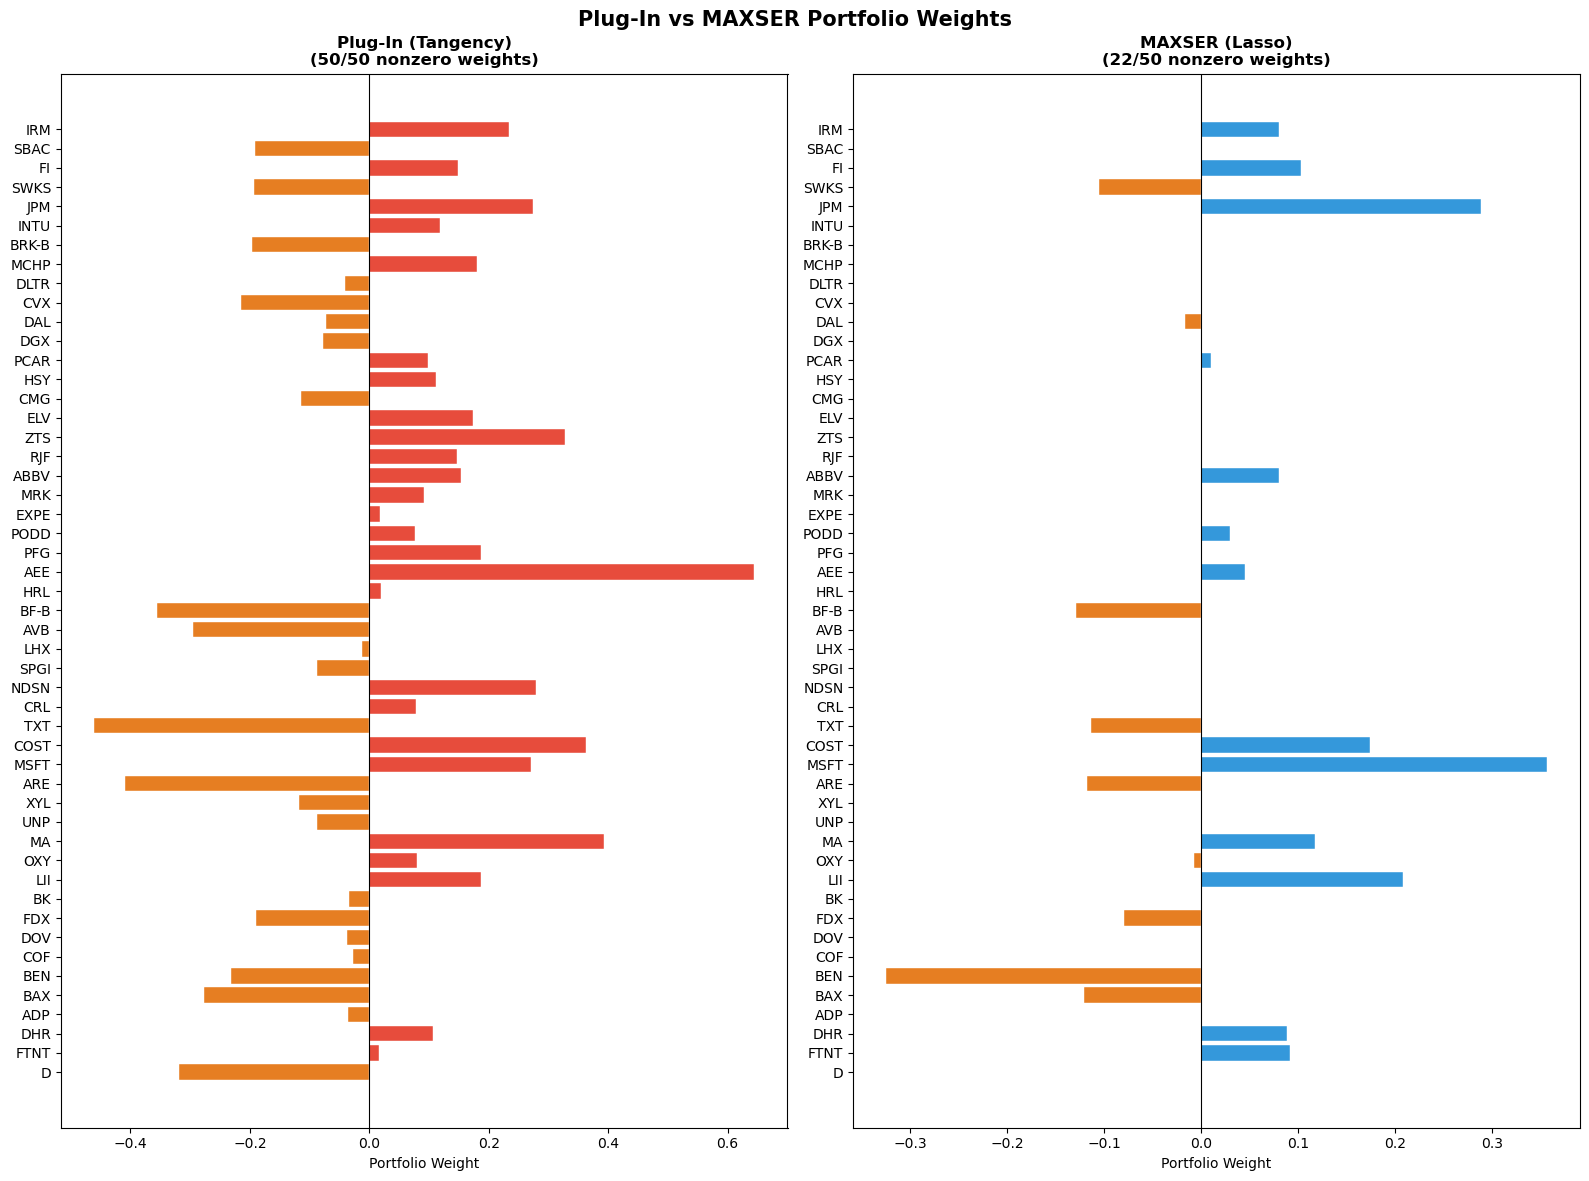

                 Metric  Plug-In  MAXSER
        Nonzero weights  50.0000 22.0000
    HHI (concentration)   2.4489  0.5221
In-sample Sharpe (ann.)   3.2568  2.3030
           Max |weight|   0.6450  0.3568
  Cash weight (1 − Σwᵢ)   0.3041  0.3416


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


sigma_monthly = sigma_m

# ── Real MAXSER weights (from cell 19) ──────────────────────────────────────
maxser_w = weights_series
nonzero_mask = np.abs(maxser_w) > 1e-6

# ── Real plug-in weights scaled to sigma_monthly ─────────────────────────────
# Formula (Assignment 4.4): w_plugin = (sigma_monthly / sqrt(theta_s)) * Sigma_inv @ mu_hat
mu_sub = subpool.mean(axis=0).values
Sigma_sub = subpool.cov().values
Sigma_sub_inv = np.linalg.inv(Sigma_sub)

plugin_w = pd.Series(
    (sigma_monthly / np.sqrt(theta_s)) * (Sigma_sub_inv @ mu_sub), index=subpool.columns
)

print(f"Plugin cash weight (1 - sum): {1 - plugin_w.sum():.4f}")

# ── (a) Side-by-side bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

for ax, weights, title, pos_color in zip(
    axes,
    [plugin_w, maxser_w],
    ["Plug-In (Tangency)", "MAXSER (Lasso)"],
    ["#e74c3c", "#3498db"],
):
    colors = [pos_color if w >= 0 else "#e67e22" for w in weights]
    ax.barh(
        weights.index, weights.values, color=colors, edgecolor="white", linewidth=0.3
    )
    ax.axvline(0, color="black", linewidth=0.8)
    nz = int(np.sum(np.abs(weights) > 1e-6))
    ax.set_title(f"{title}\n({nz}/50 nonzero weights)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Portfolio Weight")

plt.suptitle("Plug-In vs MAXSER Portfolio Weights", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("weights_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── (b) Comparison table ─────────────────────────────────────────────────────
R = subpool.values  # (121 x 50) — actual monthly returns


def sharpe_ratio(w_series, R_mat):
    port_ret = R_mat @ w_series.values
    return port_ret.mean() / port_ret.std() * np.sqrt(12)


metrics = pd.DataFrame(
    {
        "Metric": [
            "Nonzero weights",
            "HHI (concentration)",
            "In-sample Sharpe (ann.)",
            "Max |weight|",
            "Cash weight (1 − Σwᵢ)",
        ],
        "Plug-In": [
            int(np.sum(np.abs(plugin_w) > 1e-6)),
            round(float(np.sum(plugin_w**2)), 4),
            round(sharpe_ratio(plugin_w, R), 4),
            round(float(np.max(np.abs(plugin_w))), 4),
            round(float(1 - plugin_w.sum()), 4),
        ],
        "MAXSER": [
            int(nonzero_mask.sum()),
            round(float(np.sum(maxser_w**2)), 4),
            round(sharpe_ratio(maxser_w, R), 4),
            round(float(np.max(np.abs(maxser_w))), 4),
            round(float(1 - maxser_w.sum()), 4),
        ],
    }
)

print(metrics.to_string(index=False))

In [16]:
subpool

,D,FTNT,DHR,ADP,BAX,BEN,COF,DOV,FDX,BK,...,CVX,DLTR,MCHP,BRK-B,INTU,JPM,SWKS,FI,SBAC,IRM
0,0.002158,0.035200,-0.014096,-0.006663,-0.004699,-0.037033,0.000642,-0.037187,-0.054305,0.018564,...,-0.003230,0.027362,-0.052933,-0.005666,-0.006558,-0.026781,0.084820,0.016529,-0.070316,-0.001791
1,0.009764,0.075202,-0.037820,-0.014528,0.001897,0.003065,0.023828,0.089598,0.022997,0.053245,...,0.054701,-0.061786,-0.027285,-0.023385,0.035137,0.048312,-0.065021,-0.024531,-0.012591,-0.057695
2,-0.008938,0.057933,0.051082,0.009683,-0.025415,-0.014412,0.036096,-0.000764,0.019572,0.022080,...,-0.067152,-0.020484,0.035988,0.010871,0.035642,0.037338,0.169757,0.030607,-0.036962,0.054095
3,-0.055185,0.029171,-0.008956,-0.059866,0.046600,-0.036681,0.049391,-0.073784,-0.017084,-0.034622,...,-0.067536,0.049927,-0.037255,-0.051421,-0.035031,0.027617,-0.051333,0.030851,0.025831,-0.149564
4,0.067734,0.142175,0.065420,-0.007756,0.051685,-0.075628,-0.080856,-0.093093,0.003962,0.035389,...,-0.088462,-0.014234,-0.103789,0.045555,0.048837,0.015808,-0.086453,0.045501,0.046797,-0.033131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,-0.005151,0.186054,-0.027817,0.056148,-0.055454,0.088280,0.165111,0.083181,0.096848,0.079641,...,0.091361,0.094427,-0.069861,0.065553,0.047002,0.114809,-0.003100,0.107005,-0.012851,-0.003700
117,-0.090484,-0.009596,-0.045639,-0.045782,-0.148578,-0.102848,-0.077549,-0.096660,-0.071767,-0.067119,...,-0.115116,0.046631,-0.176413,-0.067129,-0.024413,-0.044492,0.016728,-0.076506,-0.108083,-0.159780
118,0.028026,0.061954,-0.033705,0.030926,0.106697,0.088175,0.129528,0.078649,-0.063879,0.113842,...,0.026002,-0.025035,-0.058238,0.029799,-0.045820,0.110504,-0.002688,0.046817,-0.034686,-0.037849
119,0.026973,0.065009,-0.072905,0.036095,0.059736,-0.097021,-0.015945,-0.025061,-0.010749,0.031258,...,0.069038,-0.009986,0.084833,0.088710,0.017008,-0.013247,-0.279145,0.083770,0.094711,-0.089606


In [17]:
mu_sub

array([-0.00068874,  0.02077606,  0.01251891,  0.0103938 , -0.0012792 ,
       -0.00669198,  0.00656483,  0.00902947,  0.0019903 ,  0.00644421,
        0.01280724, -0.00378271,  0.01334927,  0.005723  ,  0.00951618,
        0.00091345,  0.0173632 ,  0.01555932,  0.00201636,  0.00427055,
        0.00701953,  0.01215058,  0.00781159,  0.003014  , -0.00153862,
       -0.0002011 ,  0.00771226,  0.00534165,  0.01585392,  0.00451679,
        0.00475238,  0.0116276 ,  0.0100876 ,  0.00933046,  0.00733188,
        0.00942731,  0.00445963,  0.00847908,  0.00701293,  0.00055092,
        0.00454733, -0.00341988,  0.00629709,  0.00813076,  0.01363571,
        0.01175173, -0.00307941,  0.01241069,  0.00307045,  0.01000885])

In [18]:
Sigma_sub_inv.shape

(50, 50)